# Data measurement of standard observables

This notebook implements the data measurement of standard kinematic observables using the ATLAS Omnifold Z+jets measurement. Results are compared to MadGraph+Pythia8 and Sherpa theory predictions.

See `standard_obs_pseudo_results.ipynb` for the pseudodata-based closure test that validates the measurement method.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import io
import numpy as np
import uproot
import awkward as ak
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from collections import OrderedDict
from matplotlib.backends.backend_pdf import PdfPages
from common_utils import make_hists_with_uncertainty
from visualize import draw_plot, figs_to_grid

In [3]:
with open("plot_config.yml") as f:
    cfg = yaml.safe_load(f)

features = cfg["features"]
features_ylog = cfg["features_ylog"]
ibu_bins = OrderedDict({k: np.asarray(v) for k, v in cfg["bins"].items()})
plot_labels = cfg["plot_labels"]
labels = cfg["labels"]

## Preliminaries: load all data

In [ ]:
staging_dir = "/global/cfs/cdirs/m3246/ZjetOmnifold/data/final_public_data"
tree_name = "OmniTree"

truth_mc_path = f"{staging_dir}/truth_mc_events.root"
truth_hv_path = f"{staging_dir}/truth_mc_hv_events.root"
truth_madgraph_path = f"{staging_dir}/truth_madgraph/truth_madgraph_events.root"
truth_sherpa_path = f"{staging_dir}/truth_sherpa/truth_sherpa_events.root"

In [5]:
# Load event weights for data measurement
data_weights = pd.read_hdf(f"{staging_dir}/data_weights.h5")
data_hv_weights = pd.read_hdf(f"{staging_dir}/data_hv_weights.h5")
truth_madgraph_weights = pd.read_hdf(f"{staging_dir}/truth_madgraph/truth_madgraph_weights.h5")
truth_sherpa_weights = pd.read_hdf(f"{staging_dir}/truth_sherpa/truth_sherpa_weights.h5")

In [6]:
# Load truth-level features from ROOT files (already filtered to truth_pT_ll > 200)
def load_features(path):
    with uproot.open(path) as f:
        t = f[tree_name]
        return {feat: ak.to_numpy(t[f"truth_{feat}"].array()) for feat in features}

mc_features = load_features(truth_mc_path)
hv_features = load_features(truth_hv_path)
mg_features = load_features(truth_madgraph_path)
sh_features = load_features(truth_sherpa_path)

## Jet observable selection: minimal hadronic activity requirement

For jet observables (any feature involving `trackj`), we require the subleading track-jet to have $p_T > 5$ GeV. This ensures a minimal level of hadronic activity in the event and avoids a region where jet reconstruction is unreliable. Lepton and global event observables (`HT_tracks`, `Ntracks`, etc.) are computed from the full event sample without this requirement.

In [7]:
# Split features into lepton and jet observables.
# Jet observables require subleading jet pT > 5 GeV (minimal hadronic activity).
lepton_feature_names = [f for f in features if "trackj" not in f]
jet_feature_names = [f for f in features if "trackj" in f]

mc_jet_mask = mc_features["pT_trackj2"] > 5
hv_jet_mask = hv_features["pT_trackj2"] > 5
mg_jet_mask = mg_features["pT_trackj2"] > 5
sh_jet_mask = sh_features["pT_trackj2"] > 5

def _apply_jet_mask(features_dict, mask, feat_names):
    return {f: features_dict[f][mask] for f in feat_names}

def _mask_weights(weights_dict, mask):
    return {k: v[mask] for k, v in weights_dict.items()}

## Measurement with data

In [8]:
# Build weight dictionaries
n_init_weights = [name for name in data_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in data_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [name for name in data_weights.keys() if "weights_bootstrap_mc_" in name]

data_weights_dict = {
    "nominal": data_weights["weights_nominal"].to_numpy(),
    **{f"ensemble_{i}": data_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": data_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": data_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_train_weights)},
    "trackEffMain": data_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": data_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": data_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": data_weights["weights_trackPtScale"].to_numpy(),
    "muCalID": data_weights["weights_muCalID"].to_numpy(),
    "muCalMS": data_weights["weights_muCalMS"].to_numpy(),
    "muCalResBias": data_weights["weights_muCalResBias"].to_numpy(),
    "muCalScale": data_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": data_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": data_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": data_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": data_weights["weights_muEffTrig"].to_numpy(),
    "pileup": data_weights["weights_pileup"].to_numpy(),
    "lumi": data_weights["weights_lumi"].to_numpy(),
    "theoryQCD": data_weights["weights_theoryQCD"].to_numpy(),
    "theoryPDF": data_weights["weights_theoryPDF"].to_numpy(),
    "theoryAlphaS": data_weights["weights_theoryAlphaS"].to_numpy(),
    "theoryPSsoft": data_weights["weights_theoryPSsoft"].to_numpy(),
    "theoryPSjet": data_weights["weights_theoryPSjet"].to_numpy(),
    "theoryPSscale": data_weights["weights_theoryPSscale"].to_numpy(),
    "theoryMPI": data_weights["weights_theoryMPI"].to_numpy(),
    "topBackground": data_weights["weights_topBackground"].to_numpy(),
    "nonstrongDiboson": data_weights["weights_nonstrongDiboson"].to_numpy(),
    "nonstrongEW": data_weights["weights_nonstrongEW"].to_numpy(),
    "dd": data_weights["weights_dd"].to_numpy(),
    "target_dd": data_weights["target_dd"].to_numpy(),
    "hvhad": data_weights["weights_hvhad"].to_numpy(),
}

data_hv_weights_dict = {
    "nominal": data_hv_weights["weights_hv"].to_numpy(),
}

# Use weights_* key names so UncertaintyCalculator.get_total_theory_uncertainty can find them
mg_truth_weights_dict = {
    "nominal": truth_madgraph_weights["weights_nominal"].to_numpy(),
    "weights_theoryQCD": truth_madgraph_weights["weights_theoryQCD"].to_numpy(),
    "weights_theoryPDF": truth_madgraph_weights["weights_theoryPDF"].to_numpy(),
    "weights_theoryAlphaS": truth_madgraph_weights["weights_theoryAlphaS"].to_numpy(),
    "weights_theoryPSjet": truth_madgraph_weights["weights_theoryPSjet"].to_numpy(),
    "weights_theoryPSsoft": truth_madgraph_weights["weights_theoryPSsoft"].to_numpy(),
    "weights_theoryMPI": truth_madgraph_weights["weights_theoryMPI"].to_numpy(),
    "weights_theoryPSscale": truth_madgraph_weights["weights_theoryPSscale"].to_numpy(),
}

sh_truth_weights_dict = {
    "nominal": truth_sherpa_weights["weights_nominal"].to_numpy(),
    "weights_theoryQCD": truth_sherpa_weights["weights_theoryQCD"].to_numpy(),
    "weights_theoryPDF": truth_sherpa_weights["weights_theoryPDF"].to_numpy(),
    "weights_theoryAlphaS": truth_sherpa_weights["weights_theoryAlphaS"].to_numpy(),
}

In [9]:
# Compute measurement histograms (MC reweighted to data + HV uncertainty).
# Jet observables use only events with subleading jet pT > 5 GeV.
omni_features_results = {
    **make_hists_with_uncertainty(
        data=mc_features, bins=ibu_bins, observables=lepton_feature_names,
        weights_dict=data_weights_dict,
    ),
    **make_hists_with_uncertainty(
        data=_apply_jet_mask(mc_features, mc_jet_mask, jet_feature_names),
        bins=ibu_bins, observables=jet_feature_names,
        weights_dict=_mask_weights(data_weights_dict, mc_jet_mask),
    ),
}
hv_features_results = {
    **make_hists_with_uncertainty(
        data=hv_features, bins=ibu_bins, observables=lepton_feature_names,
        weights_dict=data_hv_weights_dict,
    ),
    **make_hists_with_uncertainty(
        data=_apply_jet_mask(hv_features, hv_jet_mask, jet_feature_names),
        bins=ibu_bins, observables=jet_feature_names,
        weights_dict=_mask_weights(data_hv_weights_dict, hv_jet_mask),
    ),
}
for obs in features:
    omni_features_results[obs]["hv"] = hv_features_results[obs]["nominal"]

# Compute theory prediction histograms
mg_truth_features_results = {
    **make_hists_with_uncertainty(
        data=mg_features, bins=ibu_bins, observables=lepton_feature_names,
        weights_dict=mg_truth_weights_dict,
    ),
    **make_hists_with_uncertainty(
        data=_apply_jet_mask(mg_features, mg_jet_mask, jet_feature_names),
        bins=ibu_bins, observables=jet_feature_names,
        weights_dict=_mask_weights(mg_truth_weights_dict, mg_jet_mask),
    ),
}
sh_truth_features_results = {
    **make_hists_with_uncertainty(
        data=sh_features, bins=ibu_bins, observables=lepton_feature_names,
        weights_dict=sh_truth_weights_dict,
    ),
    **make_hists_with_uncertainty(
        data=_apply_jet_mask(sh_features, sh_jet_mask, jet_feature_names),
        bins=ibu_bins, observables=jet_feature_names,
        weights_dict=_mask_weights(sh_truth_weights_dict, sh_jet_mask),
    ),
}

## IBU results

In [ ]:
from common_utils import json_to_hist

# TODO: update these paths when IBU JSON files are available on NERSC
ibu_data_jet_obs = "/path/to/IBU_data_pass200andSideBin_jetVars.json"
ibu_data_nom_obs = "/path/to/IBU_data_pass200andSideBin_nomVars.json"

nom_vars = {"pT_l1", "pT_l2", "eta_l1", "eta_l2", "phi_l1", "phi_l2", "pT_ll", "y_ll"}
ibu_results = {
    feature: json_to_hist(
        ibu_data_nom_obs if feature in nom_vars else ibu_data_jet_obs,
        bins=ibu_bins[feature],
        var=feature,
    )
    for feature in features
}

## Plotting

Individual per-feature PDFs are saved to `plots/data/<feature>.pdf`. Grid overviews of all cross-section and uncertainty-budget plots are saved to `plots/data/all_xsec_grid.pdf` and `plots/data/all_budget_grid.pdf`.
Note that a Gaussian kernel smoothing is by default applied to all observables except the track-jet masses.
See the usage recommendations for more details.

In [12]:
os.makedirs("plots/data", exist_ok=True)

xsec_figs = []
budget_figs = []

for feature in features:
    fig, fig_budget = draw_plot(
        omni_results=omni_features_results[feature],
        mgfxfx_truth_results=mg_truth_features_results[feature],
        sherpa_truth_results=sh_truth_features_results[feature],
        # ibu_results=ibu_results[feature],
        binning=ibu_bins[feature],
        ylabel=labels[feature],
        xlabel=plot_labels[feature],
        draw_uncertainty_budget=True,
        is_xSec=True,
        is_omni_data=True,
        ratio_ylim=[0.2, 1.8],
        logyScale=features_ylog[feature],
        pdf_name=f"plots/data/{feature}.pdf",
        smooth_hv=False if feature in ["m_trackj1", "m_trackj2"] else True,
    )
    xsec_figs.append(fig)
    if fig_budget is not None:
        budget_figs.append(fig_budget)
    plt.close(fig)
    if fig_budget is not None:
        plt.close(fig_budget)

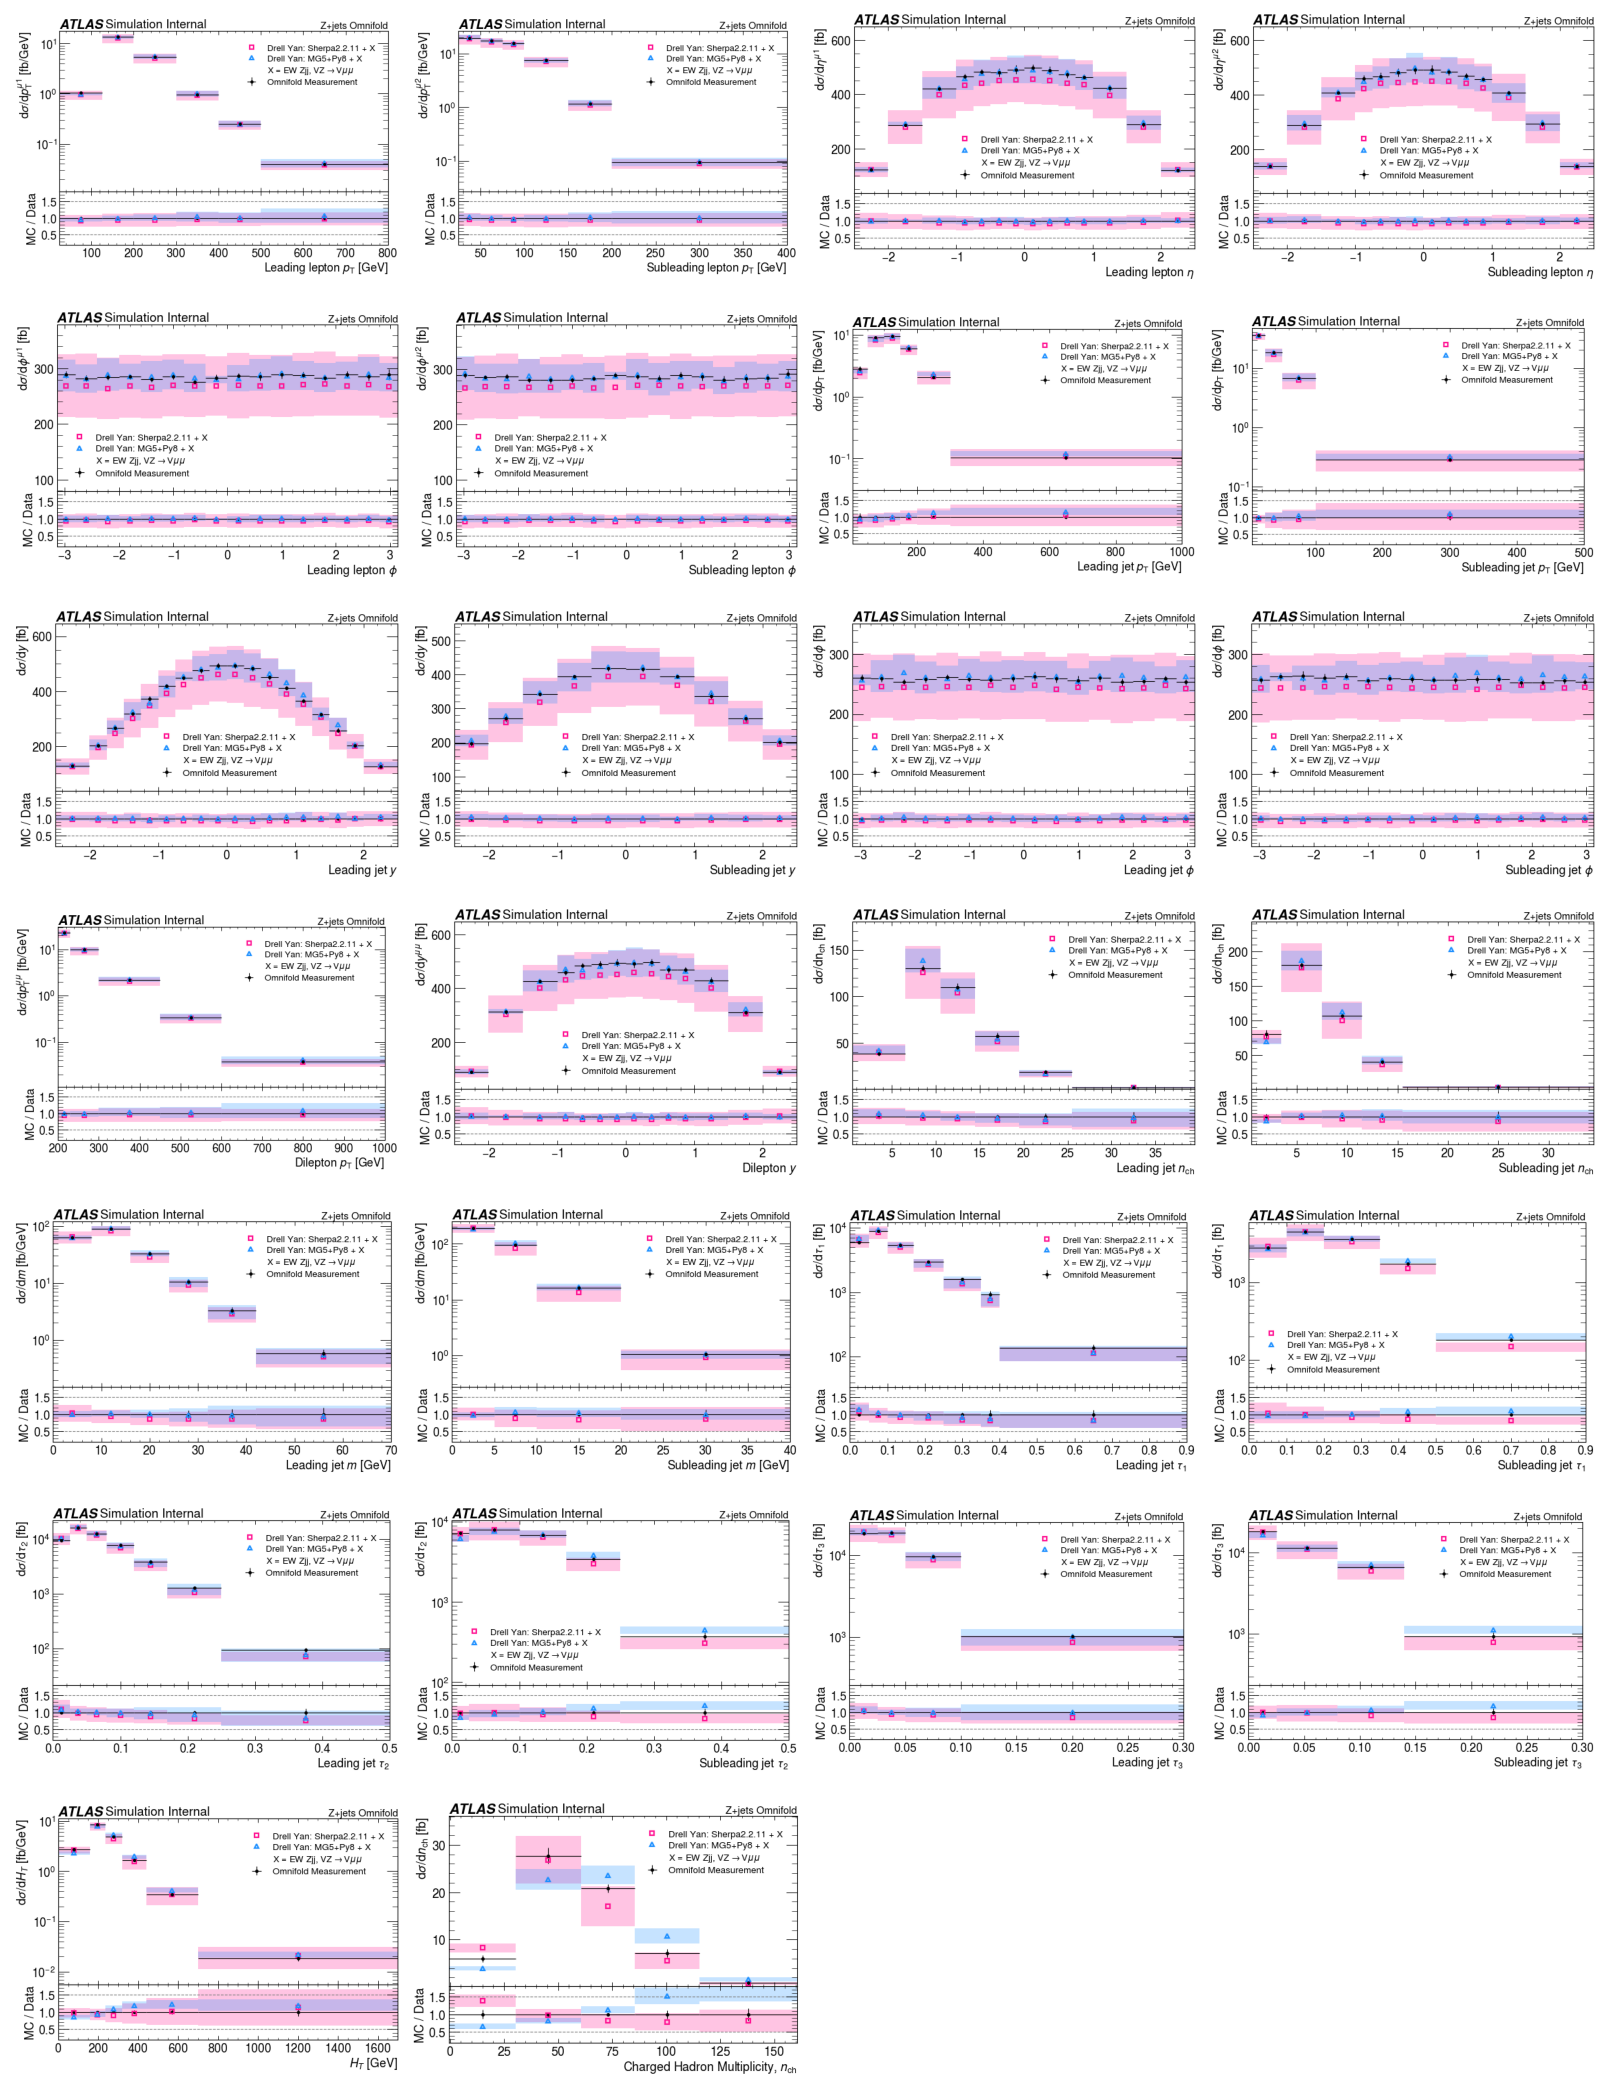

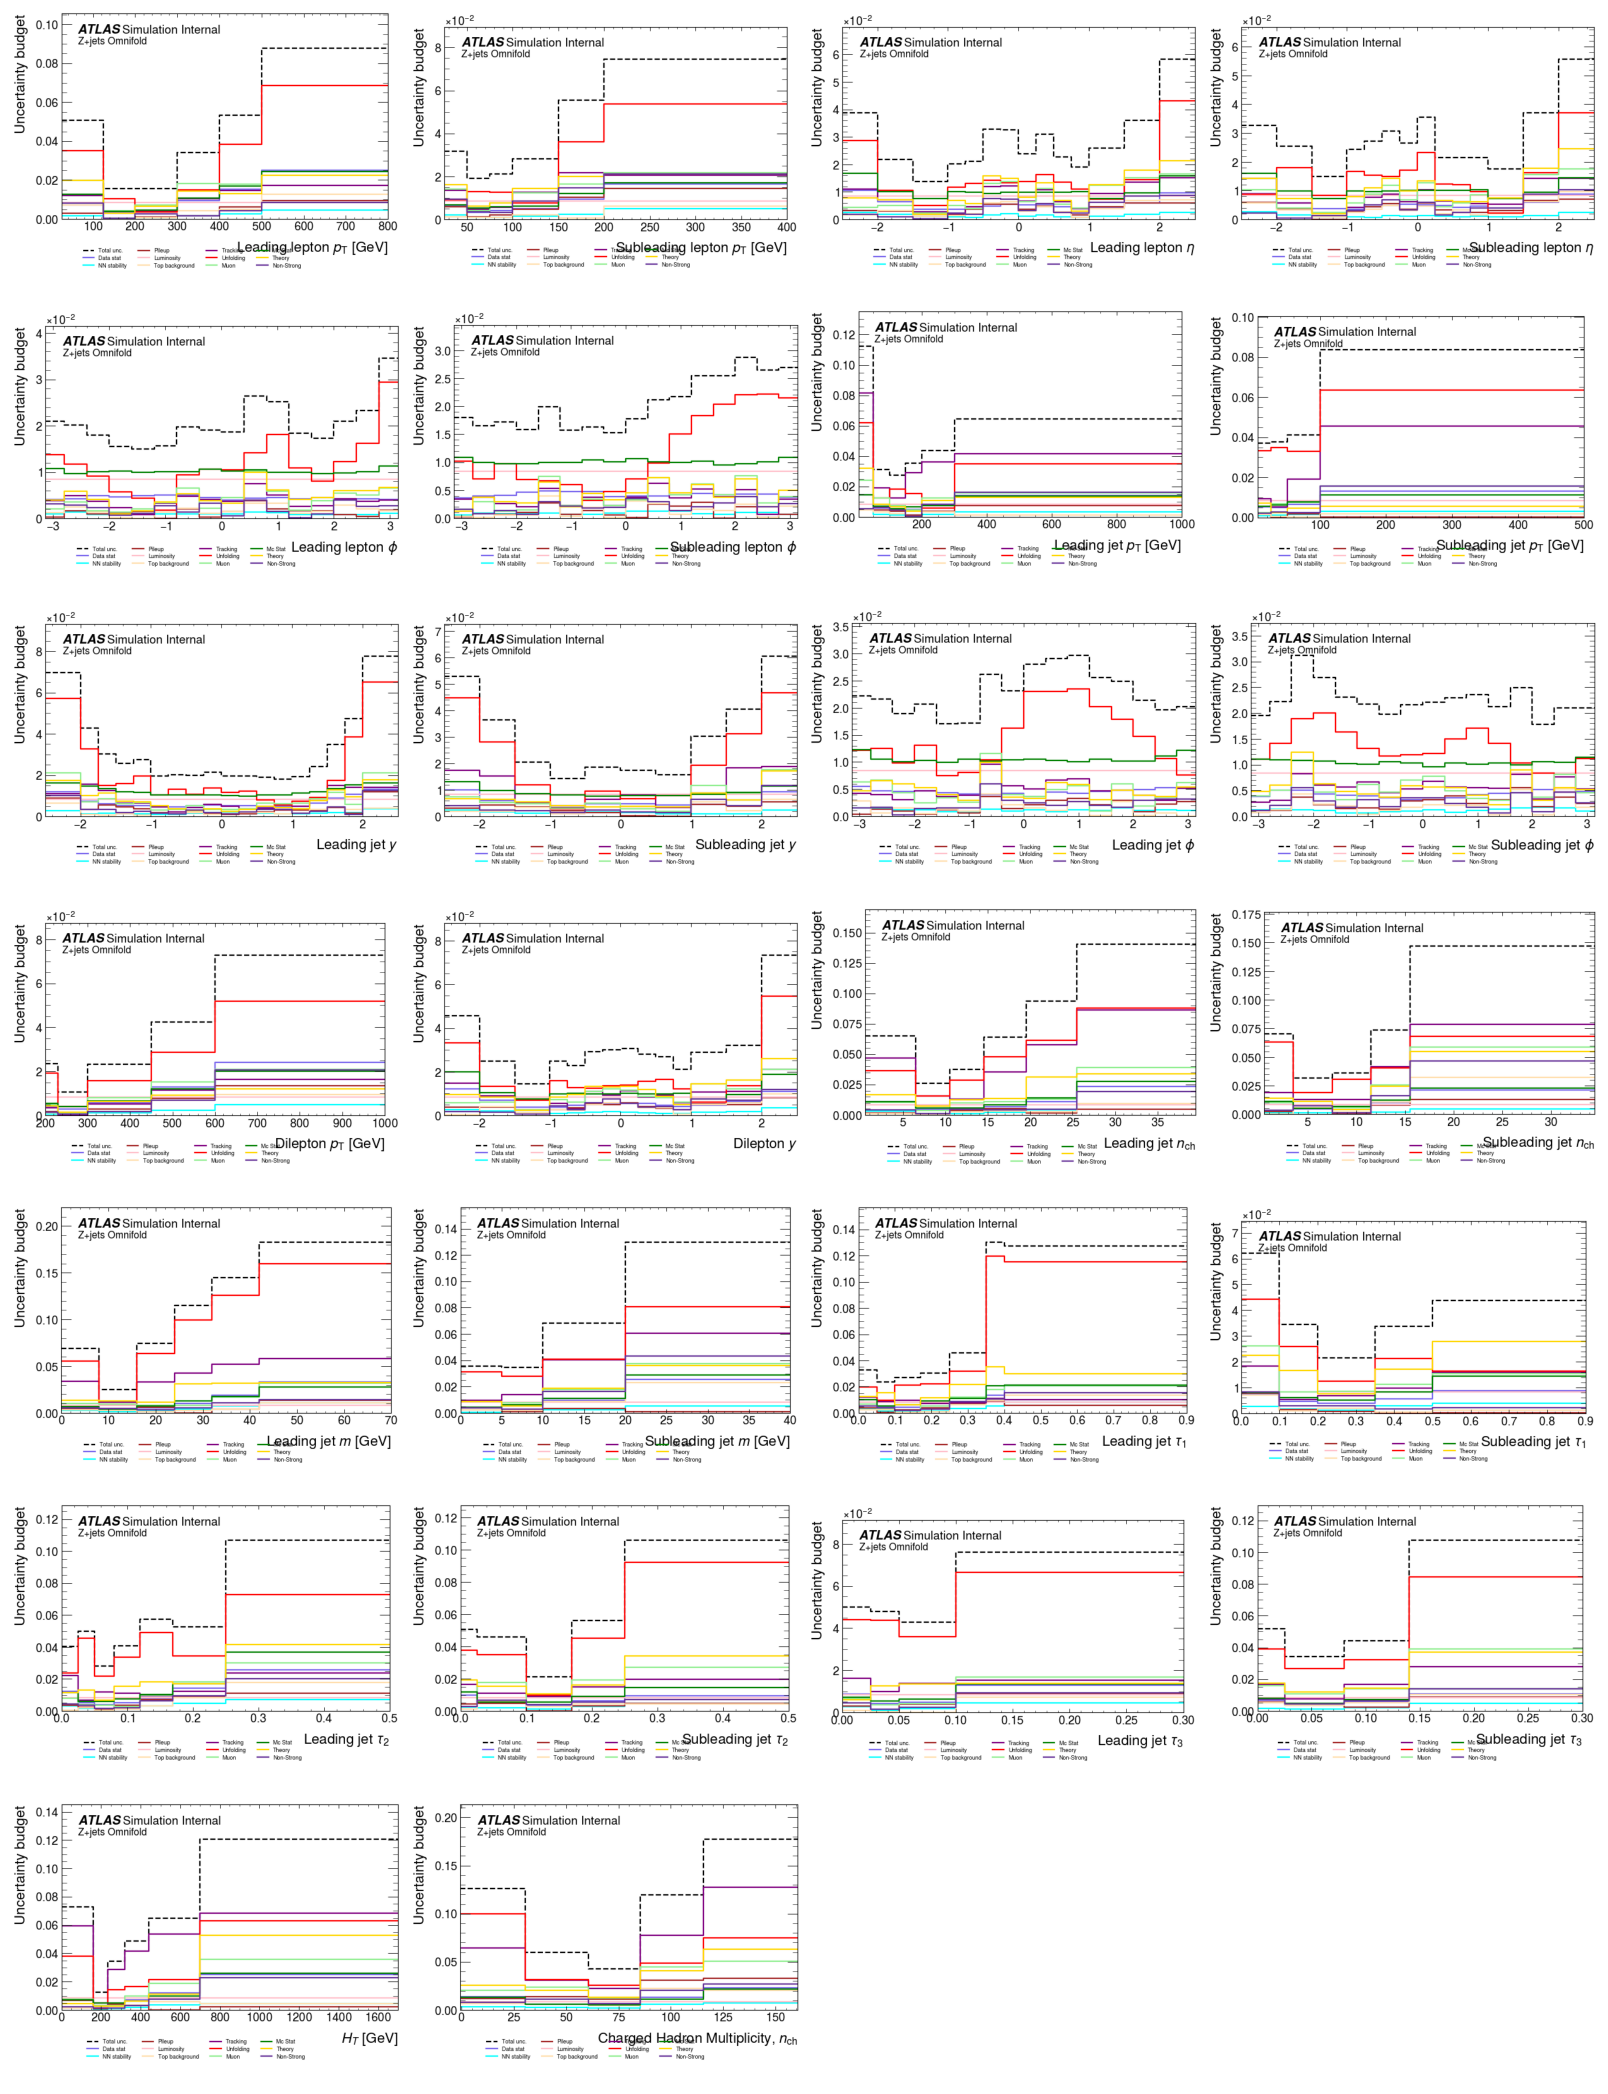

In [13]:
grid_xsec = figs_to_grid(xsec_figs, ncols=4)
grid_budget = figs_to_grid(budget_figs, ncols=4)

with PdfPages("plots/data/all_xsec_grid.pdf") as pdf:
    pdf.savefig(grid_xsec, bbox_inches="tight")
with PdfPages("plots/data/all_budget_grid.pdf") as pdf:
    pdf.savefig(grid_budget, bbox_inches="tight")

grid_xsec.show()
grid_budget.show()